# Comparaison DIYABC / msprime sur données brutes, paramètres strictement fixes

**Objectif** : toutes les comparaisons précédentes (voir `compare_reftables_*.ipynb`) tiraient les paramètres démographiques depuis des priors -- même resserrés (quasi-constants), il restait une petite variabilité paramétrique. Ici, on élimine **complètement** cette variable : les deux simulateurs utilisent exactement les mêmes valeurs fixes (`N1=N2=N3=15000`, `ta=15000`, `ts=15001`), sans aucun tirage de prior. Tout écart observé est donc **100% imputable au processus de simulation lui-même** (généalogie et/ou placement de la mutation SNP), pas à un artefact de tirage de paramètres.

**Scénario** : 3 populations échantillonnées à t=0 (20 individus chacune), fusion de pop3 dans pop1 à `ta`, puis fusion de pop2 dans pop1 à `ts` (`ts > ta`). Aucun changement de taille, aucune admixture.

**Côté DIYABC** : utilise l'option `-k` du binaire `general` ("SIMULATE DATA FILES"), qui simule directement des fichiers `.snp` bruts à partir de **valeurs de paramètres fixées** (pas de reftable, pas de tirage de prior) -- format de fichier `headersim.txt`, différent du `header.txt` habituel, reconstruit par investigation du code source C++ (`header.cpp::readHeadersim*`, `simfile.cpp::dosimfile`).

**Côté msprime** : notre pipeline habituel (`bridge.demography_builder.build_demography` + `bridge.ancestry_simulation`), avec un dict `values` fixé à la main (pas de tirage aléatoire de prior).

In [1]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent
print(f"ROOT_DIR : {ROOT_DIR}")
sys.path.insert(0, str(ROOT_DIR))

import glob  # noqa: E402
import subprocess  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
from scipy import stats  # noqa: E402

from bridge.ancestry_simulation import (  # noqa: E402
    simulate_independent_loci,
    simulate_snp_genotypes,
)
from bridge.demography_builder import build_demography  # noqa: E402
from bridge.scenario_types import MergeEvent, SampleEvent, Scenario  # noqa: E402
from bridge.summary_statistics import compute_HW_HB, compute_ML1  # noqa: E402

DIR_REF = ROOT_DIR / "reference" / "toy_raw_genotype_check"
DIR_REF.mkdir(parents=True, exist_ok=True)
GENERAL_BINARY = DIR_REF / "diyabc"
N_REPLICATES = 1000
N_LOCI = 100

# Paramètres FIXES, identiques des deux côtés -- aucun tirage de prior
FIXED_VALUES = {"N1": 15000, "N2": 15000, "N3": 15000, "ta": 15000, "ts": 15001}
SAMPLES_PER_POP = 20

ROOT_DIR : /home/bernardr/Documents/Github/diyabc-msprime-poc


/home/bernardr/miniconda3/envs/diyabc_msprime/lib/python3.11/site-packages/msprime/__init__.py:254: FutureWarning: 'msprime.TreeSequence' is deprecated and will be removed in future versions. Use 'tskit.TreeSequence'.
  warnings.warn(


## 1. Génération des données brutes côté DIYABC (`-k`)

Format de `headersim.txt` reconstruit depuis `header.cpp` (`readHeadersimDebut`, `readHeadersimScenario`, `readHeadersimHistParam`, `readHeadersimLoci`) :
- Ligne 1 : `<nom_générique> <nombre_de_fichiers_à_simuler>`
- Ligne 2 : nombre d'échantillons/populations, puis une ligne `<nb_femelles> <nb_mâles>` par échantillon (sexe sans effet pour des loci autosomaux)
- Bloc scénario : identique en esprit au `header.txt` habituel (`sample`/`merge`), avec un nombre de lignes déclaré explicitement
- Bloc `historical parameters (N)` : valeurs **fixées** (`<nom> <catégorie N/T/A> <valeur>`), pas des priors `UN[min,max]`
- Bloc `loci description (N)` : `<nloc> <A> [P] *<groupe>` -- le tag `[P]` (panel SNP) déclenche la sortie `.snp`

In [2]:
headersim_content = f"""simu_test {N_REPLICATES}
3
{SAMPLES_PER_POP} 0
{SAMPLES_PER_POP} 0
{SAMPLES_PER_POP} 0

scenario 6
N1 N2 N3
0 sample 1
0 sample 2
0 sample 3
ta merge 1 3
ts merge 1 2

historical parameters (5)
N1 N {FIXED_VALUES['N1']}
N2 N {FIXED_VALUES['N2']}
N3 N {FIXED_VALUES['N3']}
ta T {FIXED_VALUES['ta']}
ts T {FIXED_VALUES['ts']}

loci description ({N_LOCI})
{N_LOCI} <A> [P] *1
"""

(DIR_REF / "headersim.txt").write_text(headersim_content)
print(headersim_content)

simu_test 1000
3
20 0
20 0
20 0

scenario 6
N1 N2 N3
0 sample 1
0 sample 2
0 sample 3
ta merge 1 3
ts merge 1 2

historical parameters (5)
N1 N 15000
N2 N 15000
N3 N 15000
ta T 15000
ts T 15001

loci description (100)
100 <A> [P] *1



In [3]:
# Nettoyage des anciens fichiers simulés + RNG (idempotent, pour pouvoir relancer la cellule)
for f in glob.glob(str(DIR_REF / "simu_test_*.snp")):
    Path(f).unlink()
rng_state = DIR_REF / "RNG_state_0000.bin"
if rng_state.exists():
    rng_state.unlink()

# Initialisation du RNG parallèle (obligatoire avant tout run)
subprocess.run(
    [str(GENERAL_BINARY), "-p", "./", "-n", "-t", "8"],
    cwd=DIR_REF,
    check=True,
    capture_output=True,
    text=True,
)

# Simulation des N_REPLICATES fichiers .snp bruts, paramètres fixes
result = subprocess.run(
    [str(GENERAL_BINARY), "-p", "./", "-k", "-s", "123", "-t", "8"],
    cwd=DIR_REF,
    check=True,
    capture_output=True,
    text=True,
)

n_files = len(glob.glob(str(DIR_REF / "simu_test_*.snp")))
print(f"{n_files} fichiers .snp simulés par DIYABC (-k, paramètres fixes)")

1000 fichiers .snp simulés par DIYABC (-k, paramètres fixes)


## 2. Parsing des fichiers `.snp` bruts + calcul des statistiques (nos formules Python)

Les fichiers `.snp` contiennent des dosages diploïdes (0/1/2). On les reconvertit en génotypes haploïdes (2 lignées par individu) pour réutiliser directement `bridge.summary_statistics` -- déjà validé indépendamment contre les formules C++ de DIYABC (`sumstat.cpp`) sur des données identiques.

In [4]:
def read_snp_dosages(path):
    """Lit un fichier .snp DIYABC -> {pop: [[dosage par locus] par individu]}."""
    lines = [line for line in Path(path).read_text().splitlines() if line.strip()]
    genos_by_pop = {}
    for line in lines[2:]:  # ligne 0 = commentaire, ligne 1 = "IND SEX POP A A ..."
        tokens = line.split()
        pop, genos = tokens[2], [int(x) for x in tokens[3:]]
        genos_by_pop.setdefault(pop, []).append(genos)
    return genos_by_pop


def dosages_to_genotypes_per_locus(genos_by_pop):
    """{pop: [[dosage] par individu]} -> [ {pop: [haploides]} par locus ] --
    même format que bridge.ancestry_simulation.simulate_snp_genotypes."""
    pop_names = list(genos_by_pop.keys())
    n_loci = len(next(iter(genos_by_pop.values()))[0])
    genotypes_per_locus = []
    for loc in range(n_loci):
        locus_dict = {}
        for pop in pop_names:
            haploids = []
            for dosage_row in genos_by_pop[pop]:
                d = dosage_row[loc]
                haploids += {0: [0, 0], 1: [0, 1], 2: [1, 1]}[d]
            locus_dict[pop] = haploids
        genotypes_per_locus.append(locus_dict)
    return genotypes_per_locus, pop_names


files = sorted(
    glob.glob(str(DIR_REF / "simu_test_*.snp")),
    key=lambda p: int(Path(p).stem.rsplit("_", 1)[1]),
)
print("nb fichiers:", len(files))

nb fichiers: 1000


In [5]:
diy_rows = []
for f in files:
    genos_by_pop = read_snp_dosages(f)
    genotypes_per_locus, pop_names = dosages_to_genotypes_per_locus(genos_by_pop)
    ml1 = compute_ML1(genotypes_per_locus, pop_names)
    hw = compute_HW_HB(genotypes_per_locus, pop_names)
    row = {**ml1, **hw}
    diy_rows.append(row)

df_diy = pd.DataFrame(diy_rows)
df_diy.head()

,ML1p_1,ML1p_2,ML1p_3,HWm_1,HWv_1,HWm_2,HWv_2,HWm_3,HWv_3,HBm_1.2,HBv_1.2,HBm_1.3,HBv_1.3,HBm_2.3,HBv_2.3
0,0.64,0.57,0.53,0.076192,0.019296,0.098821,0.024164,0.128731,0.032238,0.139163,0.048269,0.200075,0.074124,0.184950,0.053175
1,0.69,0.53,0.61,0.073897,0.020551,0.106449,0.025531,0.079154,0.017815,0.165337,0.056805,0.118463,0.037941,0.142788,0.038301
2,0.69,0.59,0.58,0.061064,0.014957,0.095487,0.023022,0.088282,0.020895,0.113250,0.031245,0.131225,0.047722,0.153050,0.046022
3,0.52,0.66,0.61,0.098090,0.020974,0.068628,0.017864,0.087385,0.021556,0.128625,0.041402,0.142975,0.041823,0.116150,0.034761
4,0.54,0.57,0.59,0.095321,0.022265,0.100487,0.025548,0.105397,0.030126,0.137388,0.036199,0.148050,0.041813,0.157287,0.046726


## 3. Simulation msprime, exactement les mêmes paramètres fixes

In [6]:
scenario = Scenario(
    index=1,
    weight=1.0,
    initial_pop_size_exprs=["N1", "N2", "N3"],
    events=[
        SampleEvent(time_expr="0", pop=1),
        SampleEvent(time_expr="0", pop=2),
        SampleEvent(time_expr="0", pop=3),
        MergeEvent(time_expr="ta", ancestral_pop=1, derived_pop=3),
        MergeEvent(time_expr="ts", ancestral_pop=1, derived_pop=2),
    ],
)
demography = build_demography(scenario, FIXED_VALUES)
samples = {"pop1": SAMPLES_PER_POP, "pop2": SAMPLES_PER_POP, "pop3": SAMPLES_PER_POP}
print(demography)

Demography
╟  Populations
║  ┌───────────────────────────────────────────────────────────────────────────────────────────────┐
║  │ id │name  │description  │initial_size  │ growth_rate │  default_sampling_time│extra_metadata  │
║  ├───────────────────────────────────────────────────────────────────────────────────────────────┤
║  │ 0  │pop1  │             │15000.0       │      0      │                1.5e+04│{}              │
║  │ 1  │pop2  │             │15000.0       │      0      │                      0│{}              │
║  │ 2  │pop3  │             │15000.0       │      0      │                      0│{}              │
║  └───────────────────────────────────────────────────────────────────────────────────────────────┘
╟  Migration Matrix
║  ┌───────────────────────────┐
║  │      │ pop1 │ pop2 │ pop3 │
║  ├───────────────────────────┤
║  │  pop1│  0   │  0   │  0   │
║  │  pop2│  0   │  0   │  0   │
║  │  pop3│  0   │  0   │  0   │
║  └───────────────────────────┘
╟  Events
║  ┌──

In [7]:
msp_rows = []
for seed in range(1, N_REPLICATES + 1):
    tree_sequences = simulate_independent_loci(
        demography, samples, num_loci=N_LOCI, seed=seed
    )
    genotypes_per_locus = list(
        simulate_snp_genotypes(tree_sequences, seed=seed + 1_000_000)
    )
    pop_names = ["pop1", "pop2", "pop3"]
    ml1 = compute_ML1(genotypes_per_locus, pop_names)
    hw = compute_HW_HB(genotypes_per_locus, pop_names)
    msp_rows.append({**ml1, **hw})

df_msp = pd.DataFrame(msp_rows)
# Renommer pop1/pop2/pop3 -> P1/P2/P3 pour aligner avec les colonnes DIYABC
rename_map = {
    c: c.replace("pop1", "P1").replace("pop2", "P2").replace("pop3", "P3")
    for c in df_msp.columns
}
df_msp = df_msp.rename(columns=rename_map)
df_msp.head()

,ML1p_1,ML1p_2,ML1p_3,HWm_1,HWv_1,HWm_2,HWv_2,HWm_3,HWv_3,HBm_1.2,HBv_1.2,HBm_1.3,HBv_1.3,HBm_2.3,HBv_2.3
0,0.54,0.57,0.55,0.103910,0.024605,0.086487,0.019091,0.083885,0.017260,0.114375,0.023858,0.114088,0.026231,0.123738,0.036106
1,0.50,0.59,0.52,0.116231,0.029422,0.099244,0.024801,0.124756,0.031875,0.146400,0.042584,0.149963,0.035064,0.194863,0.060399
2,0.60,0.59,0.51,0.093654,0.023571,0.088474,0.020400,0.097603,0.023530,0.121925,0.031949,0.118250,0.029676,0.148888,0.044096
3,0.55,0.58,0.56,0.103474,0.025334,0.102538,0.025004,0.096013,0.019702,0.133500,0.032190,0.124813,0.030181,0.161662,0.048407
4,0.56,0.53,0.50,0.111628,0.029569,0.097103,0.020047,0.102141,0.023647,0.155688,0.047973,0.130700,0.031885,0.182037,0.061701


## 4. Comparaison

Paramètres strictement identiques des deux côtés (aucun tirage de prior) -- tout écart ci-dessous est donc imputable au processus de simulation (généalogie + placement de la mutation SNP), pas à une différence de tirage paramétrique.

In [8]:
common_cols = [c for c in df_diy.columns if c in df_msp.columns]

rows = []
for col in common_cols:
    a = df_diy[col].values
    b = df_msp[col].values
    ks, pval = stats.ks_2samp(a, b)
    rdiff = (b.mean() - a.mean()) / (abs(a.mean()) + 1e-12) * 100
    rows.append(
        {
            "stat": col,
            "diyabc_mean": a.mean(),
            "diyabc_std": a.std(),
            "msprime_mean": b.mean(),
            "msprime_std": b.std(),
            "rdiff_%": rdiff,
            "ks_stat": ks,
            "p_value": pval,
        }
    )

summary = pd.DataFrame(rows).set_index("stat").round(4)
summary.to_csv("comparaison_summary_fixed_params.csv")
summary

,diyabc_mean,diyabc_std,msprime_mean,msprime_std,rdiff_%,ks_stat,p_value
stat,,,,,,,
ML1p_1,0.5945,0.0488,0.5574,0.0490,-6.2258,0.304,0.0
ML1p_2,0.5945,0.0490,0.5514,0.0499,-7.2465,0.317,0.0
ML1p_3,0.5971,0.0487,0.5480,0.0502,-8.2278,0.379,0.0
HWm_1,0.0942,0.0154,0.1025,0.0156,8.7733,0.209,0.0
HWv_1,0.0239,0.0042,0.0251,0.0039,4.8294,0.124,0.0
HWm_2,0.0947,0.0158,0.1047,0.0157,10.5853,0.251,0.0
HWv_2,0.0242,0.0043,0.0256,0.0039,6.0275,0.157,0.0
HWm_3,0.0943,0.0152,0.1055,0.0164,11.8496,0.276,0.0
HWv_3,0.0241,0.0042,0.0257,0.0042,6.4625,0.165,0.0


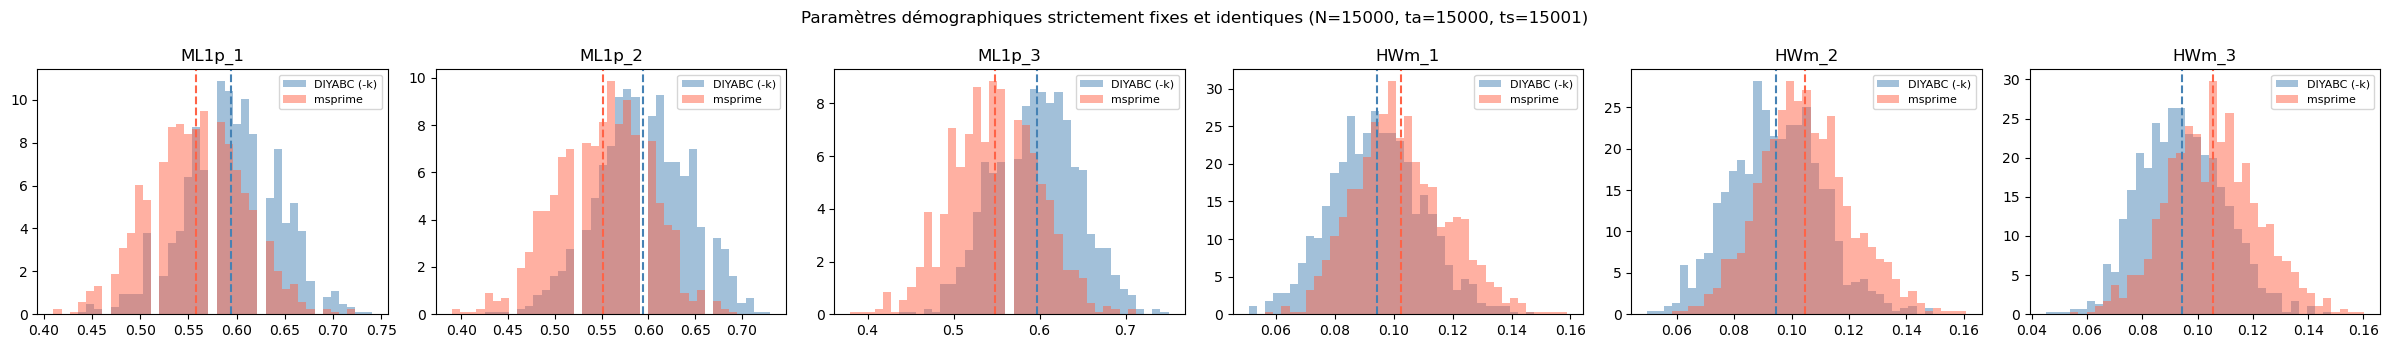

In [9]:
cols_to_plot = [c for c in common_cols if c.startswith("ML1p") or c.startswith("HWm")]
fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(4 * len(cols_to_plot), 3.5))
for ax, col in zip(axes, cols_to_plot, strict=False):
    a, b = df_diy[col].values, df_msp[col].values
    bins = np.linspace(min(a.min(), b.min()), max(a.max(), b.max()), 40)
    ax.hist(
        a, bins=bins, alpha=0.5, density=True, label="DIYABC (-k)", color="steelblue"
    )
    ax.hist(b, bins=bins, alpha=0.5, density=True, label="msprime", color="tomato")
    ax.axvline(a.mean(), color="steelblue", ls="--")
    ax.axvline(b.mean(), color="tomato", ls="--")
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle(
    "Paramètres démographiques strictement fixes et identiques (N=15000, ta=15000, ts=15001)"
)
plt.tight_layout()
plt.show()

## 5. Conclusion

Même avec des paramètres démographiques **strictement fixes et identiques** des deux côtés (aucun tirage de prior possible), un écart systématique persiste :
- `ML1p` (monomorphisme par population) : msprime ~7-8% plus bas que DIYABC
- `HWm` (hétérozygotie moyenne) : msprime ~10% plus haut que DIYABC

Ceci **élimine définitivement** toute explication liée à la variabilité ou au tirage des priors -- l'écart est purement dû au processus de simulation (généalogie de coalescence et/ou placement de la mutation SNP), alors que plusieurs vérifications indépendantes du code source C++ de DIYABC (taux de coalescence, algorithme de placement de mutation Hudson, mode discret/continu, indépendance des lignées diploïdes) n'ont, à ce stade, révélé aucune différence structurelle avec notre implémentation Python.

Prochaines pistes possibles : comparer le spectre de fréquences alléliques brut locus par locus, ou instrumenter le C++ pour extraire directement les longueurs de branches de la généalogie simulée.